In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import os.path
import logging
import argparse
import datetime
import mrcfile
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from PIL import Image
import sys
import time
import pickle
sys.path.append("/home/bcl/wanghongyu/wanghongyu_humx/dynamic/ssem")
sys.path.append("/home/bcl/wanghongyu/wanghongyu_humx/dynamic/ssem/models")
sys.path.append("/home/bcl/wanghongyu/wanghongyu_humx/dynamic/tools")
from visualization.vis import plot_images
from models.wasserstein2_loss import Wasserstein2Loss
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
with h5py.File('/home/bcl/wanghongyu/wanghongyu_humx/dynamic/ssem/data/sampleA/sample_A+_20160601.hdf', 'r') as f:
    for name in f:
        print(":", name)
    data_type = f["__DATA_TYPES__"]
    raw_data = f['volumes/raw']
    dataset = np.array(raw_data)

: __DATA_TYPES__
: volumes

Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

This is taking too long, we give up.


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

This is taking too long, we give up.



In [4]:
x = torch.from_numpy(dataset).unsqueeze(1).float()  # shape (N,1,H,W)
scale_h = 4
scale_w = 4
pool = torch.nn.AvgPool2d(kernel_size=(scale_h, scale_w))
data = pool(x).squeeze(1).numpy()

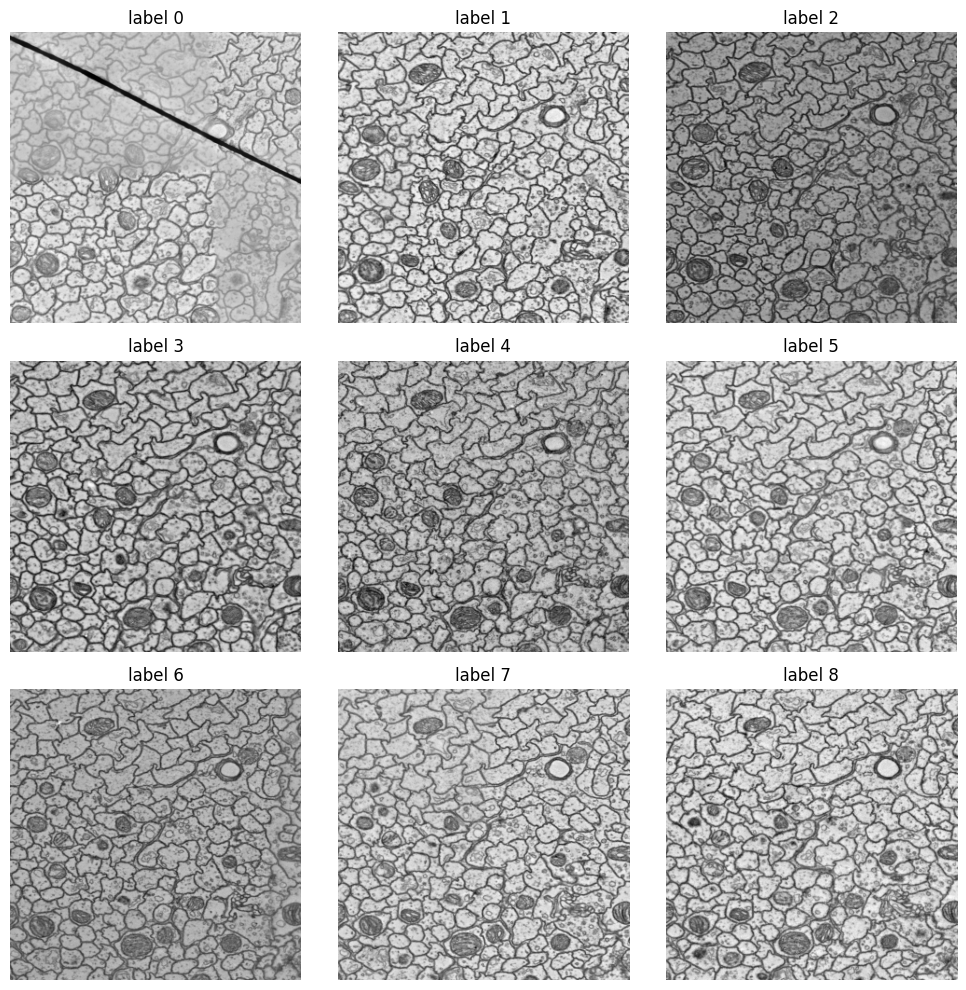

In [5]:
# images = [data[:,:,5*it] for it in range(9)]
images = data[:9]
plot_images(images, size = (3,3), resize_to_square=True)

In [6]:
data_t = torch.from_numpy(data)
data_t = data_t.to('cuda')
for i in range(19):
    print(data[i].max(),data[i].min(),data[i].sum(),data[i].mean(),data[i].std())

178.1875 0.0 1.2293569e+07 126.28995 25.506496
168.625 44.875 1.2420188e+07 127.59069 25.540997
231.125 36.3125 1.242894e+07 127.680595 28.604418
191.9375 41.9375 1.2416803e+07 127.555916 29.096071
174.75 65.9375 1.2414439e+07 127.53163 19.415901
175.375 28.9375 1.2419859e+07 127.58731 27.173164
206.0625 28.8125 1.2428348e+07 127.674515 25.451471
178.8125 28.8125 1.245578e+07 127.95632 26.104483
166.1875 53.25 1.2495313e+07 128.36244 21.626331
167.5625 61.25 1.252643e+07 128.6821 21.892262
165.9375 59.8125 1.2525476e+07 128.6723 19.777033
167.3125 31.25 1.2505214e+07 128.46414 23.126833
180.375 52.3125 1.2481687e+07 128.22246 23.907207
230.25 47.1875 1.2455282e+07 127.9512 25.061287
176.375 32.875 1.2430831e+07 127.70002 26.463789
179.125 14.5625 1.2402702e+07 127.41106 25.052313
171.3125 12.0625 1.2378381e+07 127.16121 23.229988
173.875 29.3125 1.2367568e+07 127.05013 25.188717
196.4375 45.6875 1.2358696e+07 126.95899 27.128668


In [17]:
from models.deform import LDDMM
lddmm = LDDMM(image_shape=data_t[0].shape, time_steps=10, reg_weight=0.001, w2_paras={'eps': 1e-8, 'maxiter': 100})
lddmm.to('cuda')

LDDMM(
  (w2): Wasserstein2Loss()
)

In [20]:
weights = torch.tensor([0.05,0.15,0.3,0.3,0.15,0.05], device='cuda')
source = data_t[0].unsqueeze(0)
neighbors = torch.cat([data_t[1:4], data_t[5:8]], dim=0)

In [ ]:
# 梯度下降循环框架

# 假设 lddmm, source, neighbors, weights 已经在上面定义并在 cuda 上
import torch.optim as optim

# 需要保证 source, neighbors 形状为 (B, 1, H, W) 或 (N, 1, H, W)
# 这里只做简单举例(B=1情况，可按需更改)
source_tensor = source.unsqueeze(0) if source.ndim == 3 else source
neighbors_tensor = neighbors.unsqueeze(1) if neighbors.ndim == 3 else neighbors

optimizer = optim.Adam(lddmm.parameters(), lr=1e-2)
num_steps = 200

for step in range(num_steps):
    optimizer.zero_grad()
    out = lddmm(source_tensor, neighbors_tensor, weights)
    loss = out['loss_total']
    loss.backward()
    optimizer.step()
    print(f"Step {step+1:3d} | loss: {loss.item():.4f} | w2: {out['loss_w2'].item():.4f} | reg: {out['loss_reg'].item():.4f}")

In [ ]:
warped = out['warped']
flow = out['flow']
images = torch.cat([neighbors[:3], source_tensor, warped, torch.zeros_like(warped), neighbors[3:]], dim=0)
plot_images(images, size = (3,3), resize_to_square=True)

#### W2 test

In [33]:
W2 = Wasserstein2Loss(eps=1e-8, maxiter=500)
for i,j in [(1,1), (0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]:
    loss_value = W2(data_t[i].unsqueeze(0), data_t[j].unsqueeze(0))
    print(loss_value.item())

0.48066139221191406
6.654748439788818
7.395631790161133
7.478206157684326
4.062399864196777
4.951114654541016
3.909243106842041


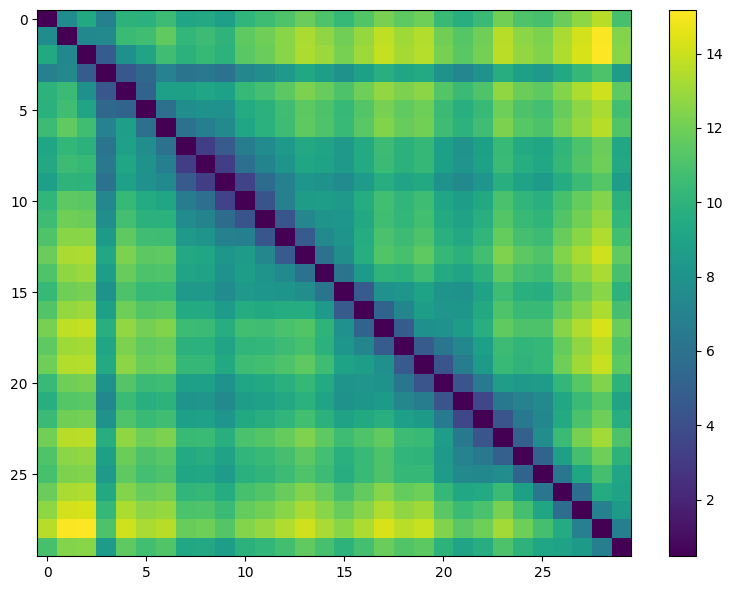

In [26]:
from visualization.vis import plot_heatmap
loss_mat = W2(data_t[1:31], data_t[1:31])
# print(loss_mat)
plot_heatmap(loss_mat.cpu().numpy())

In [34]:
T1 = time.perf_counter()
loss_mat = W2(data_t[1:11], data_t[1:11])
T2 = time.perf_counter()
print(T2 - T1)

/home/bcl/wanghongyu/wanghongyu_humx/dynamic/ssem/models/gpu_utils.py:10: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  def torch_to_cupy(x): return cp.fromDlpack(to_dlpack(x))


12.51674746349454


/home/bcl/wanghongyu/wanghongyu_humx/dynamic/ssem/models/gpu_utils.py:9: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  def cupy_to_torch(x): return from_dlpack(x.toDlpack())


In [35]:
T1 = time.perf_counter()
for i in range(10):
    for j in range(i, 10):
        loss_value = W2(data_t[i+1].unsqueeze(0), data_t[j+1].unsqueeze(0))
T2 = time.perf_counter()
print(T2 - T1)

11.066630497574806
